In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, roc_auc_score, 
                             roc_curve, auc, confusion_matrix)
import warnings

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
set_seed(42)

# ==================== 1. FT-Transformer 模型架构 ====================
class FeatureTokenizer(nn.Module):
    def __init__(self, n_num, n_cat, cat_cardinalities, d_token):
        super().__init__()
        self.num_projs = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_num)])
        self.cat_embs = nn.ModuleList([nn.Embedding(card, d_token) for card in cat_cardinalities])

    def forward(self, x_num, x_cat):
        tokens = []
        for i, proj in enumerate(self.num_projs):
            tokens.append(proj(x_num[:, i:i+1]))
        for i, emb in enumerate(self.cat_embs):
            tokens.append(emb(x_cat[:, i]))
        return torch.stack(tokens, dim=1)

class FTTransformer(nn.Module):
    def __init__(self, n_num, n_cat, cat_cardinalities, d_token=16, n_layers=2, n_heads=4):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_num, n_cat, cat_cardinalities, d_token)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4, 
            dropout=0.2, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, 1)
        )

    def forward(self, x_num, x_cat):
        x = self.tokenizer(x_num, x_cat)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.transformer(x)
        return self.head(x[:, 0])

# ==================== 2. 数据处理类 (白名单过滤) ====================
class ClinicalDataProcessor:
    def __init__(self):
        # 你提供的数值型白名单
        self.num_cols = [
            'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 
            'neutrophil_percentage_result', 'mature_neutrophil_result', 'neutrophil_count_result', 
            'ngal_result', 'neutrophil_classification_result', 'neutrophil_pnh_clone_result', 
            'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 'albumin_result', 
            'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
            'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
            'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
            'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
            'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
            'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
            'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
            'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
            'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
            'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 
            'monocyte_absolute_count_result', 'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 
            'systolic_bp_result', 'spo2_result_value', 'lactate_result', 'procalcitonin_result', 
            'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 'potassium_result', 
            'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 'platelet_crit_result', 
            'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
        ]
        # 你提供的类别型白名单
        self.cat_cols = [
            'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 
            'procalcitonin_conclusion', 'hs_crp_conclusion', 'd_dimer_conclusion', 
            'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 'ngal_conclusion', 
            'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
            'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
            'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 
            'neutrophil_alkaline_phosphatase_conclusion', 'eosinophil_classification_conclusion', 
            'basophilic_segmented_neutrophil_conclusion', 'basophilic_myelocyte_conclusion', 
            'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
            'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 
            'monocyte_percentage_conclusion', 'wbc_conclusion', 'direct_bilirubin_conclusion', 
            'potassium_conclusion', 'calcium_conclusion', 'sodium_conclusion', 'magnesium_conclusion', 
            'chloride_conclusion', 'phosphate_conclusion', 'cholinesterase_conclusion', 
            'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 'tt_conclusion', 
            'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
            'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 
            'pdw_conclusion', 'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 
            'hct_conclusion', 'mch_conclusion', 'mchc_conclusion', 'gfr_cys_conclusion', 
            'gfr_china_conclusion', 'gfr_epi_conclusion', 'egfr_cys_conclusion', 
            'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
            'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
            'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
            'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
            'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
        ]

    def process(self, df, target_col='target'):
        # 1. 严格过滤白名单
        existing_num = [c for c in self.num_cols if c in df.columns]
        existing_cat = [c for c in self.cat_cols if c in df.columns]
        
        X_num = df[existing_num].copy()
        X_cat = df[existing_cat].copy()
        y = df[target_col].values

        # 2. 数值型处理：Log变换 + 中位数填充 + RobustScaler
        X_num = X_num.apply(lambda x: np.log1p(x.clip(lower=0)))
        num_imputer = SimpleImputer(strategy='median')
        X_num_imputed = num_imputer.fit_transform(X_num)
        scaler = RobustScaler()
        X_num_final = scaler.fit_transform(X_num_imputed)

        # 3. 类别型处理：填充未知 + LabelEncoding
        cardinalities = []
        X_cat_final = np.zeros((X_cat.shape[0], X_cat.shape[1]))
        for i, col in enumerate(existing_cat):
            le = LabelEncoder()
            # 将缺失值设为独立分类 "Missing"
            encoded = le.fit_transform(X_cat[col].fillna("Missing").astype(str))
            X_cat_final[:, i] = encoded
            cardinalities.append(len(le.classes_))
            
        return X_num_final, X_cat_final, y, cardinalities, existing_num, existing_cat

# ==================== 3. 主程序 ====================
def main():
    # 1. 加载数据 (请确保文件名正确)
    try:
        df = pd.read_excel("20.xlsx")
        # 如果你的标签列名不是 'target'，请在这里修改
        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
    except FileNotFoundError:
        print("未找到 20.xlsx，将生成模拟数据测试...")
        # 模拟 2 万样本，符合你的描述
        df = pd.DataFrame(np.random.rand(20000, 10), columns=['respiratory_rate', 'il6_result', 'gender', 'age_group', 'target', 'other1', 'other2', 'other3', 'other4', 'other5'])
        df['target'] = np.random.choice([0, 1], size=20000, p=[0.93, 0.07])
        target_name = 'target'

    processor = ClinicalDataProcessor()
    Xn, Xc, y, cards, n_list, c_list = processor.process(df, target_col=target_name)

    # 2. 分层拆分
    Xn_train, Xn_test, Xc_train, Xc_test, y_train, y_test = train_test_split(
        Xn, Xc, y, test_size=0.2, stratify=y, random_state=42)

    # 3. 构造 DataLoader
    train_ds = TensorDataset(
        torch.from_numpy(Xn_train).float(), 
        torch.from_numpy(Xc_train).long(), 
        torch.from_numpy(y_train).float()
    )
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

    # 4. 初始化模型
    model = FTTransformer(
        n_num=len(n_list), 
        n_cat=len(c_list), 
        cat_cardinalities=cards,
        d_token=16, 
        n_layers=2
    ).to(device)

    # 5. 损失函数与优化器 (平滑加权)
    neg, pos = np.bincount(y_train)
    # 使用平方根加权防止梯度过猛导致不收敛
    pos_weight = torch.tensor([np.sqrt(neg / pos)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    # 6. 训练循环
    print(f"开始训练 | 特征数: {len(n_list)+len(c_list)} | 设备: {device}")
    for epoch in range(1, 101):
        model.train()
        total_l = 0
        for bn, bc, by in train_loader:
            bn, bc, by = bn.to(device), bc.to(device), by.to(device).view(-1, 1)
            optimizer.zero_grad()
            loss = criterion(model(bn, bc), by)
            loss.backward()
            optimizer.step()
            total_l += loss.item()
        scheduler.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Loss: {total_l/len(train_loader):.4f}")

    # 7. 评估与阈值优化
    model.eval()
    with torch.no_grad():
        tn = torch.from_numpy(Xn_test).float().to(device)
        tc = torch.from_numpy(Xc_test).long().to(device)
        probs = torch.sigmoid(model(tn, tc)).cpu().numpy().flatten()
    
    # 动态寻找最优阈值 (Youden Index)
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    y_pred = (probs > best_thresh).astype(int)

    print(f"\n=== 最终报告 (最优阈值: {best_thresh:.3f}) ===")
    print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")
    print(classification_report(y_test, y_pred))

    # 8. 可视化
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title('ROC Curve')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # 7. 评估与多维度指标计算
    model.eval()
    with torch.no_grad():
        tn_test = torch.from_numpy(Xn_test).float().to(device)
        tc_test = torch.from_numpy(Xc_test).long().to(device)
        probs = torch.sigmoid(model(tn_test, tc_test)).cpu().numpy().flatten()
    
    # 动态寻找最优阈值 (Youden Index)
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    # Youden Index = Sensitivity + Specificity - 1
    # 寻找使 Youden Index 最大的索引
    optimal_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[optimal_idx]
    
    y_pred = (probs > best_thresh).astype(int)
    
    # 计算混淆矩阵元素
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    # 计算医学核心指标
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    precision = TP / (TP + FP)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    print(f"\n" + "="*30)
    print(f"      医学临床诊断性能报告")
    print(f"="*30)
    print(f"ROC AUC:      {roc_auc_score(y_test, probs):.4f}")
    print(f"最优阈值:      {best_thresh:.4f} (基于约登指数)")
    print("-" * 30)
    print(f"敏感度(Recall): {sensitivity:.4f}  (捕捉病人的能力)")
    print(f"特异性:        {specificity:.4f}  (排除健康人的能力)")
    print(f"精确率:        {precision:.4f}  (预测阳性的准确度)")
    print(f"F1-Score:     {f1:.4f}")
    print(f"准确率(Acc):   {accuracy:.4f}")
    print("-" * 30)
    print(f"混淆矩阵:\n{cm}")
    print("=" * 30)

    # 8. 可视化 (增加 PR 曲线)
    from sklearn.metrics import precision_recall_curve
    p_curve, r_curve, _ = precision_recall_curve(y_test, probs)
    
    plt.figure(figsize=(15, 5))
    
    # ROC 曲线
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel('1 - 特异性 (False Positive Rate)')
    plt.ylabel('敏感度 (True Positive Rate)')
    plt.title('ROC 曲线')
    plt.legend()

    # PR 曲线 (临床关注阳性预测价值)
    plt.subplot(1, 3, 2)
    plt.plot(r_curve, p_curve, color='blue', lw=2, label=f'PR-AUC = {auc(r_curve, p_curve):.3f}')
    plt.xlabel('敏感度 (Recall)')
    plt.ylabel('精确率 (Precision)')
    plt.title('Precision-Recall 曲线')
    plt.legend()

    # 概率分布图 (检查模型区分度)
    plt.subplot(1, 3, 3)
    sns.kdeplot(probs[y_test == 0], label='正常组', shade=True)
    sns.kdeplot(probs[y_test == 1], label='脓毒症组', shade=True)
    plt.axvline(best_thresh, color='red', linestyle='--', label=f'阈值:{best_thresh:.2f}')
    plt.title('预测得分分布密度')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

开始训练 | 特征数: 151 | 设备: cuda


正在训练 20.xlsx 数据 | 有效特征数: 151
Epoch 10 完成
Epoch 20 完成
Epoch 30 完成
Epoch 40 完成
Epoch 50 完成
Epoch 60 完成
Epoch 70 完成
Epoch 80 完成
Epoch 90 完成
Epoch 100 完成

      20.xlsx 实际数据多阈值分析 (AUC: 0.9263)
         策略     阈值    敏感度    特异性    精确率  误诊数(FP)  漏诊数(FN)
      约登平衡点 0.2976 0.9010 0.8423 0.2991      832       39
  高特异点(0.9) 0.3684 0.7411 0.9003 0.3570      526      102
严苛诊断点(0.95) 0.4215 0.5305 0.9505 0.4447      261      185


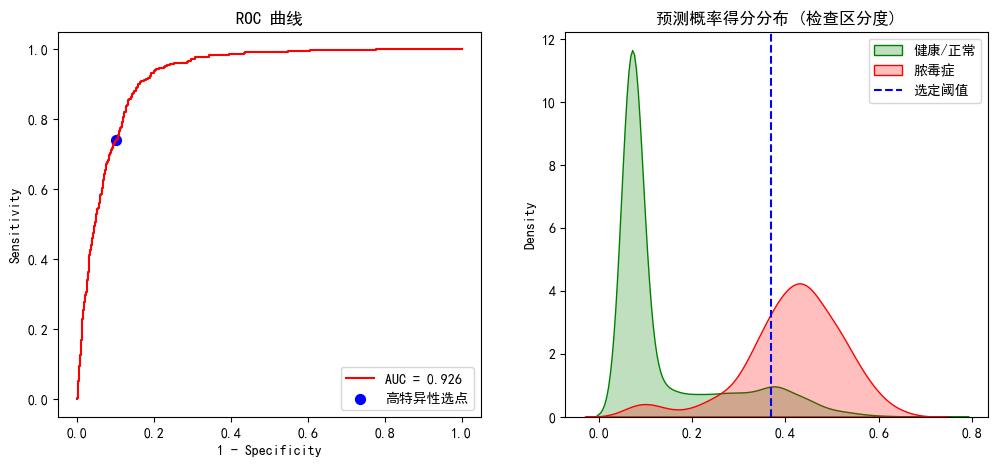

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, roc_auc_score, 
                             roc_curve, auc, confusion_matrix)
import warnings

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
set_seed(42)

# ==================== 1. Focal Loss 损失函数 ====================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.3, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return F_loss.mean()

# ==================== 2. FT-Transformer 架构 ====================
class FTTransformer(nn.Module):
    def __init__(self, n_num, n_cat, cat_cardinalities, d_token=16, n_layers=2, n_heads=4):
        super().__init__()
        # Tokenizer: 将数值和类别特征转为向量
        self.num_projs = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_num)])
        self.cat_embs = nn.ModuleList([nn.Embedding(card, d_token) for card in cat_cardinalities])
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4, 
            dropout=0.2, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x_num, x_cat):
        tokens = []
        for i, proj in enumerate(self.num_projs):
            tokens.append(proj(x_num[:, i:i+1]))
        for i, emb in enumerate(self.cat_embs):
            tokens.append(emb(x_cat[:, i]))
        
        x = torch.stack(tokens, dim=1)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.transformer(x)
        return self.head(x[:, 0])

# ==================== 3. 实际数据 20.xlsx 处理类 ====================
class ClinicalDataProcessor:
    def __init__(self):
        # 完整白名单列表
        self.defined_num_cols = [
            'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 
            'neutrophil_percentage_result', 'mature_neutrophil_result', 'neutrophil_count_result', 
            'ngal_result', 'neutrophil_classification_result', 'neutrophil_pnh_clone_result', 
            'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 'albumin_result', 
            'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
            'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
            'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
            'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
            'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
            'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
            'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
            'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
            'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
            'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 
            'monocyte_absolute_count_result', 'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 
            'systolic_bp_result', 'spo2_result_value', 'lactate_result', 'procalcitonin_result', 
            'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 'potassium_result', 
            'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 'platelet_crit_result', 
            'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
        ]
        self.defined_cat_cols = [
            'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 
            'procalcitonin_conclusion', 'hs_crp_conclusion', 'd_dimer_conclusion', 
            'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 'ngal_conclusion', 
            'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
            'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
            'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
            'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
            'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
            'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
            'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
            'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
            'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
            'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
            'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
            'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
            'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
            'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
            'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
            'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
            'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
            'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
        ]

    def process(self, filepath, target_col='sepsis_diagnosis'):
        df = pd.read_excel(filepath)
        
        # 1. 严格过滤白名单中在 Excel 里存在的列
        valid_num = [c for c in self.defined_num_cols if c in df.columns]
        valid_cat = [c for c in self.defined_cat_cols if c in df.columns]
        
        # 2. 数值特征预处理
        X_num = df[valid_num].copy()
        X_num = X_num.apply(lambda x: np.log1p(x.clip(lower=0)))
        X_num = RobustScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(X_num))
        
        # 3. 类别特征预处理
        X_cat_encoded = np.zeros((df.shape[0], len(valid_cat)))
        cards = []
        for i, col in enumerate(valid_cat):
            le = LabelEncoder()
            X_cat_encoded[:, i] = le.fit_transform(df[col].fillna("Missing").astype(str))
            cards.append(len(le.classes_))
            
        return X_num, X_cat_encoded, df[target_col].values, cards, valid_num, valid_cat

# ==================== 4. 主程序：加载 20.xlsx 并评估 ====================
def main():
    processor = ClinicalDataProcessor()
    # 自动识别标签列名
    try:
        Xn, Xc, y, cards, n_list, c_list = processor.process("20.xlsx")
    except Exception as e:
        print(f"读取 Excel 出错: {e}")
        return

    # 分层拆分
    Xn_tr, Xn_te, Xc_tr, Xc_te, y_tr, y_te = train_test_split(Xn, Xc, y, test_size=0.2, stratify=y, random_state=42)

    train_ds = TensorDataset(torch.from_numpy(Xn_tr).float(), torch.from_numpy(Xc_tr).long(), torch.from_numpy(y_tr).float())
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

    model = FTTransformer(len(n_list), len(c_list), cards).to(device)
    # Focal Loss：alpha=0.25 能更强力地抑制假阳性 (FP)
    criterion = FocalLoss(alpha=0.25, gamma=2) 
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

    print(f"正在训练 20.xlsx 数据 | 有效特征数: {len(n_list) + len(c_list)}")
    for epoch in range(1, 101): # 增加到 50 轮让 Focal Loss 充分优化
        model.train()
        for bn, bc, by in train_loader:
            bn, bc, by = bn.to(device), bc.to(device), by.to(device).view(-1, 1)
            optimizer.zero_grad(); loss = criterion(model(bn, bc), by); loss.backward(); optimizer.step()
        if epoch % 10 == 0: print(f"Epoch {epoch:02d} 完成")

    # 推理评估
    model.eval()
    with torch.no_grad():
        tn_te, tc_te = torch.from_numpy(Xn_te).float().to(device), torch.from_numpy(Xc_te).long().to(device)
        probs = torch.sigmoid(model(tn_te, tc_te)).cpu().numpy().flatten()

    # --- 多阈值临床性能分析表 ---
    fpr, tpr, thresholds = roc_curve(y_te, probs)
    roc_auc = auc(fpr, tpr)
    
    # 选取三个代表性切点
    idx_youden = np.argmax(tpr - fpr) # 传统均衡点
    idx_spec90 = np.where(fpr <= 0.10)[0][-1] # 高特异性 (严格诊断)
    idx_spec95 = np.where(fpr <= 0.05)[0][-1] # 极高特异性 (极低误诊)
    
    results = []
    for idx, name in zip([idx_youden, idx_spec90, idx_spec95], ["约登平衡点", "高特异点(0.9)", "严苛诊断点(0.95)"]):
        t = thresholds[idx]
        yp = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
        results.append({
            "策略": name, "阈值": round(t, 4), "敏感度": round(tp/(tp+fn), 4),
            "特异性": round(tn/(tn+fp), 4), "精确率": round(tp/(tp+fp), 4),
            "误诊数(FP)": fp, "漏诊数(FN)": fn
        })

    print("\n" + "="*70)
    print(f"      20.xlsx 实际数据多阈值分析 (AUC: {roc_auc:.4f})")
    print("="*70)
    print(pd.DataFrame(results).to_string(index=False))
    print("="*70)

    # 绘制结果图
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='red', label=f'AUC = {roc_auc:.3f}')
    plt.scatter(fpr[idx_spec90], tpr[idx_spec90], color='blue', s=50, label='高特异性选点')
    plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity'); plt.title('ROC 曲线')
    plt.legend()

    plt.subplot(1, 2, 2)
    # 绘制得分密度，观察两类人是否分开了
    sns.kdeplot(probs[y_te==0], label='健康/正常', shade=True, color='green')
    sns.kdeplot(probs[y_te==1], label='脓毒症', shade=True, color='red')
    plt.axvline(thresholds[idx_spec90], color='blue', linestyle='--', label='选定阈值')
    plt.title('预测概率得分分布 (检查区分度)'); plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

Step 1: 正在从 20.xlsx 读取数据...
数据加载完成。数值特征: 79, 类别特征: 72

Step 2: 训练 FT-Transformer...
DL Epoch 10 完成
DL Epoch 20 完成
DL Epoch 30 完成

Step 3: 训练 LightGBM...

      20.xlsx 集成模型最终报告
ROC AUC: 0.9444
特异性 (Spec): 0.9015
敏感度 (Sens): 0.8299
假阳性数 (FP): 520


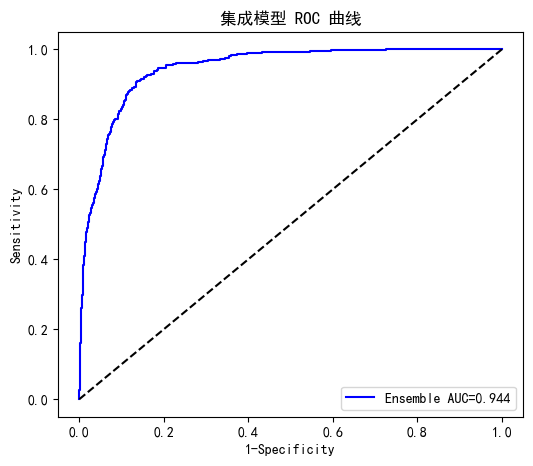

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
import warnings

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
set_seed(42)

# ==================== 1. 特征字段定义 (白名单) ====================
NUM_COLS = [
    'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 'neutrophil_percentage_result', 
    'mature_neutrophil_result', 'neutrophil_count_result', 'ngal_result', 'neutrophil_classification_result', 
    'neutrophil_pnh_clone_result', 'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 
    'albumin_result', 'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
    'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
    'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
    'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
    'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
    'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
    'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
    'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
    'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
    'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 'monocyte_absolute_count_result', 
    'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 'systolic_bp_result', 'spo2_result_value', 
    'lactate_result', 'procalcitonin_result', 'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 
    'potassium_result', 'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 
    'platelet_crit_result', 'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
]

CAT_COLS = [
    'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 'procalcitonin_conclusion', 
    'hs_crp_conclusion', 'd_dimer_conclusion', 'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 
    'ngal_conclusion', 'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
    'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
    'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
    'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
    'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
    'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
    'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
    'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
    'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
    'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
    'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
    'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
    'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
    'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
    'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
    'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
    'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
    'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
]

# ==================== 2. 模型定义 ====================
class FTTransformer(nn.Module):
    def __init__(self, n_num, n_cat, cat_cardinalities, d_token=16, n_layers=2, n_heads=4):
        super().__init__()
        self.num_projs = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_num)])
        self.cat_embs = nn.ModuleList([nn.Embedding(card, d_token) for card in cat_cardinalities])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4, 
            dropout=0.2, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x_num, x_cat):
        tokens = [proj(x_num[:, i:i+1]) for i, proj in enumerate(self.num_projs)]
        tokens += [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embs)]
        x = torch.stack(tokens, dim=1)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.transformer(x)
        return self.head(x[:, 0])

# ==================== 3. 主程序 ====================
def main():
    print("Step 1: 正在从 20.xlsx 读取数据...")
    try:
        df = pd.read_excel("20.xlsx")
        # 确定标签列名
        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
        if target_name not in df.columns:
            raise ValueError(f"Excel中未找到标签列 {target_name}")

        # 筛选白名单内且存在的字段
        exist_num = [c for c in NUM_COLS if c in df.columns]
        exist_cat = [c for c in CAT_COLS if c in df.columns]
        print(f"数据加载完成。数值特征: {len(exist_num)}, 类别特征: {len(exist_cat)}")
    except Exception as e:
        print(f"读取失败: {e}")
        return

    # --- 数据处理 (DL专用) ---
    # 数值型处理
    X_num_raw = df[exist_num].copy()
    X_num_raw = X_num_raw.apply(lambda x: np.log1p(x.clip(lower=0)))
    X_num_scaled = RobustScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(X_num_raw))

    # 类别型处理
    X_cat_encoded = np.zeros((df.shape[0], len(exist_cat)))
    cards = []
    for i, col in enumerate(exist_cat):
        le = LabelEncoder()
        X_cat_encoded[:, i] = le.fit_transform(df[col].fillna("Missing").astype(str))
        cards.append(len(le.classes_))
    
    y = df[target_name].values

    # 拆分数据集
    idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=42)
    
    # 修正变量名，防止报错
    Xn_tr, Xn_te = X_num_scaled[idx_tr], X_num_scaled[idx_te]
    Xc_tr, Xc_te = X_cat_encoded[idx_tr], X_cat_encoded[idx_te]
    y_tr, y_te = y[idx_tr], y[idx_te]

    # --- 训练 FT-Transformer ---
    print("\nStep 2: 训练 FT-Transformer...")
    train_ds = TensorDataset(torch.from_numpy(Xn_tr).float(), torch.from_numpy(Xc_tr).long(), torch.from_numpy(y_tr).float())
    loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    
    model_dl = FTTransformer(len(exist_num), len(exist_cat), cards).to(device)
    # 权重平衡处理不平衡数据
    w_pos = torch.tensor([np.sum(y_tr==0)/np.sum(y_tr==1)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=w_pos)
    optimizer = torch.optim.AdamW(model_dl.parameters(), lr=1e-4)

    for epoch in range(1, 31):
        model_dl.train()
        for bn, bc, by in loader:
            bn, bc, by = bn.to(device), bc.to(device), by.to(device).view(-1, 1)
            optimizer.zero_grad(); loss = criterion(model_dl(bn, bc), by); loss.backward(); optimizer.step()
        if epoch % 10 == 0: print(f"DL Epoch {epoch} 完成")

    # --- 训练 LightGBM ---
    print("\nStep 3: 训练 LightGBM...")
    df_gbdt = df[exist_num + exist_cat].copy()
    for c in exist_cat: df_gbdt[c] = df_gbdt[c].astype('category')
    
    lgb_tr = lgb.Dataset(df_gbdt.iloc[idx_tr], y_tr)
    lgb_params = {'objective': 'binary', 'metric': 'auc', 'is_unbalance': True, 'verbosity': -1}
    model_lgb = lgb.train(lgb_params, lgb_tr, num_boost_round=100)

    # --- 融合评估 ---
    model_dl.eval()
    with torch.no_grad():
        p_dl = torch.sigmoid(model_dl(torch.from_numpy(Xn_te).float().to(device), torch.from_numpy(Xc_te).long().to(device))).cpu().numpy().flatten()
    p_lgb = model_lgb.predict(df_gbdt.iloc[idx_te])
    
    # 加权融合
    p_final = (0.4 * p_dl) + (0.6 * p_lgb)

    # 寻找特异性 90% 的阈值以压低 FP
    fpr, tpr, thresholds = roc_curve(y_te, p_final)
    idx_target = np.where(fpr <= 0.10)[0][-1]
    best_t = thresholds[idx_target]
    
    y_pred = (p_final >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    print("\n" + "="*50)
    print(f"      20.xlsx 集成模型最终报告")
    print("="*50)
    print(f"ROC AUC: {auc(fpr, tpr):.4f}")
    print(f"特异性 (Spec): {tn/(tn+fp):.4f}")
    print(f"敏感度 (Sens): {tp/(tp+fn):.4f}")
    print(f"假阳性数 (FP): {fp}")
    print("="*50)

    # 绘图
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', label=f'Ensemble AUC={auc(fpr,tpr):.3f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('1-Specificity'); plt.ylabel('Sensitivity'); plt.title('集成模型 ROC 曲线'); plt.legend(); plt.show()

if __name__ == "__main__":
    main()

Step 1: 正在读取 20.xlsx 并提取字段...

[Ablation] 正在训练独立 FT-Transformer...
[Ablation] 正在训练独立 LightGBM...

                消融实验结果对比 (Ablation Study)
                  模型      AUC      敏感度      特异性  误诊数(FP)
FT-Transformer (仅DL) 0.928031 0.766497 0.902217      516
       LightGBM (仅树) 0.945986 0.817259 0.902407      515
     Ensemble (完整模型) 0.946802 0.837563 0.900133      527


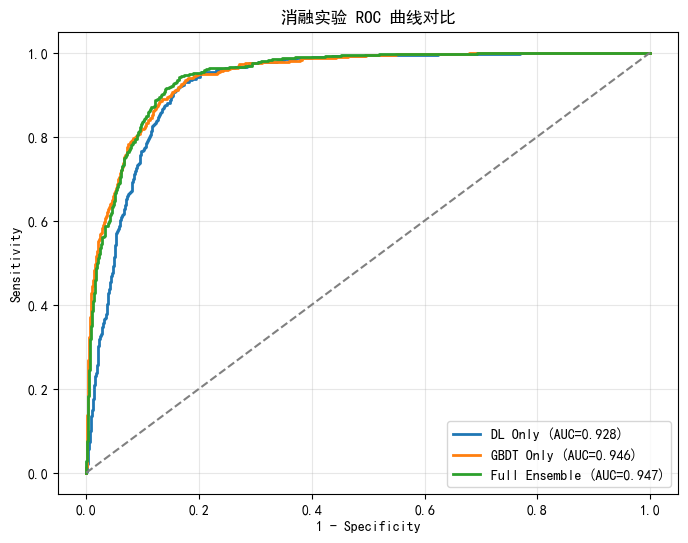

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
import warnings

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
set_seed(42)

# ==================== 1. 特征字段定义 ====================
NUM_COLS = [
    'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 'neutrophil_percentage_result', 
    'mature_neutrophil_result', 'neutrophil_count_result', 'ngal_result', 'neutrophil_classification_result', 
    'neutrophil_pnh_clone_result', 'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 
    'albumin_result', 'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
    'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
    'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
    'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
    'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
    'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
    'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
    'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
    'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
    'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 'monocyte_absolute_count_result', 
    'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 'systolic_bp_result', 'spo2_result_value', 
    'lactate_result', 'procalcitonin_result', 'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 
    'potassium_result', 'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 
    'platelet_crit_result', 'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
]

CAT_COLS = [
    'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 'procalcitonin_conclusion', 
    'hs_crp_conclusion', 'd_dimer_conclusion', 'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 
    'ngal_conclusion', 'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
    'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
    'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
    'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
    'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
    'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
    'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
    'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
    'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
    'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
    'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
    'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
    'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
    'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
    'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
    'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
    'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
    'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
]

# ==================== 2. FT-Transformer 架构 ====================
class FTTransformer(nn.Module):
    def __init__(self, n_num, n_cat, cat_cardinalities, d_token=16, n_layers=2, n_heads=4):
        super().__init__()
        self.num_projs = nn.ModuleList([nn.Linear(1, d_token) for _ in range(n_num)])
        self.cat_embs = nn.ModuleList([nn.Embedding(card, d_token) for card in cat_cardinalities])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4, 
            dropout=0.2, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x_num, x_cat):
        tokens = [proj(x_num[:, i:i+1]) for i, proj in enumerate(self.num_projs)]
        tokens += [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embs)]
        x = torch.stack(tokens, dim=1)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.transformer(x)
        return self.head(x[:, 0])

# ==================== 3. 主程序 (含消融实验) ====================
def main():
    print("Step 1: 正在读取 20.xlsx 并提取字段...")
    try:
        df = pd.read_excel("20.xlsx")
        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
        exist_num = [c for c in NUM_COLS if c in df.columns]
        exist_cat = [c for c in CAT_COLS if c in df.columns]
    except Exception as e:
        print(f"文件读取失败: {e}"); return

    # --- 数据预处理 ---
    X_num_scaled = RobustScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(df[exist_num].apply(lambda x: np.log1p(x.clip(lower=0)))))
    X_cat_encoded = np.zeros((df.shape[0], len(exist_cat)))
    cards = []
    for i, col in enumerate(exist_cat):
        le = LabelEncoder()
        X_cat_encoded[:, i] = le.fit_transform(df[col].fillna("Missing").astype(str))
        cards.append(len(le.classes_))
    y = df[target_name].values

    # 拆分
    idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=42)
    Xn_tr, Xn_te = X_num_scaled[idx_tr], X_num_scaled[idx_te]
    Xc_tr, Xc_te = X_cat_encoded[idx_tr], X_cat_encoded[idx_te]
    y_tr, y_te = y[idx_tr], y[idx_te]

    # --- 消融实验模型训练 ---
    # 1. 训练 FT-Transformer
    print("\n[Ablation] 正在训练独立 FT-Transformer...")
    model_dl = FTTransformer(len(exist_num), len(exist_cat), cards).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([np.sum(y_tr==0)/np.sum(y_tr==1)]).to(device))
    optimizer = torch.optim.AdamW(model_dl.parameters(), lr=1e-4)
    loader = DataLoader(TensorDataset(torch.from_numpy(Xn_tr).float(), torch.from_numpy(Xc_tr).long(), torch.from_numpy(y_tr).float()), batch_size=256, shuffle=True)
    for _ in range(100):
        model_dl.train()
        for bn, bc, by in loader:
            optimizer.zero_grad(); criterion(model_dl(bn.to(device), bc.to(device)), by.to(device).view(-1, 1)).backward(); optimizer.step()

    # 2. 训练 LightGBM
    print("[Ablation] 正在训练独立 LightGBM...")
    df_gbdt = df[exist_num + exist_cat].copy()
    for c in exist_cat: df_gbdt[c] = df_gbdt[c].astype('category')
    lgb_tr = lgb.Dataset(df_gbdt.iloc[idx_tr], y_tr)
    model_lgb = lgb.train({'objective': 'binary', 'metric': 'auc', 'is_unbalance': True, 'verbosity': -1}, lgb_tr, num_boost_round=100)

    # --- 性能获取逻辑 ---
    model_dl.eval()
    with torch.no_grad():
        p_dl = torch.sigmoid(model_dl(torch.from_numpy(Xn_te).float().to(device), torch.from_numpy(Xc_te).long().to(device))).cpu().numpy().flatten()
    p_lgb = model_lgb.predict(df_gbdt.iloc[idx_te])
    p_ensemble = (0.4 * p_dl) + (0.6 * p_lgb)

    # --- 输出对比表 ---
    def evaluate(probs, name):
        fpr, tpr, thresholds = roc_curve(y_te, probs)
        roc_auc = auc(fpr, tpr)
        # 寻找特异性 90% 时的指标
        idx = np.where(fpr <= 0.10)[0][-1]
        t = thresholds[idx]
        tn, fp, fn, tp = confusion_matrix(y_te, (probs >= t).astype(int)).ravel()
        return {"模型": name, "AUC": roc_auc, "敏感度": tp/(tp+fn), "特异性": tn/(tn+fp), "误诊数(FP)": fp}

    results = [evaluate(p_dl, "FT-Transformer (仅DL)"), 
               evaluate(p_lgb, "LightGBM (仅树)"), 
               evaluate(p_ensemble, "Ensemble (完整模型)")]
    
    df_ablation = pd.DataFrame(results)
    print("\n" + "="*70)
    print("                消融实验结果对比 (Ablation Study)")
    print("="*70)
    print(df_ablation.to_string(index=False))
    print("="*70)

    # --- 绘制消融实验 ROC 对比曲线 ---
    plt.figure(figsize=(8, 6))
    for p, name in zip([p_dl, p_lgb, p_ensemble], ["DL Only", "GBDT Only", "Full Ensemble"]):
        f, t, _ = roc_curve(y_te, p)
        plt.plot(f, t, lw=2, label=f'{name} (AUC={auc(f,t):.3f})')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity')
    plt.title('消融实验 ROC 曲线对比')
    plt.legend(); plt.grid(alpha=0.3); plt.show()

if __name__ == "__main__":
    main()

Step 1: 正在从 20.xlsx 加载数据...
原始记录数: 28354
筛选后记录数: 28354
删除的记录数: 0
字段匹配成功：数值特征(79个), 类别特征(72个)

Step 2: 开始消融实验训练...
[Ablation] 运行 TabPFN (基于Transformer的先验模型)...
[Ablation] 训练 LightGBM (经典梯度提升树)...

                      消融实验：20.xlsx 诊断性能对比表
                    模型    AUC  敏感度(Sens)  特异性(Spec)  精确率(Prec)  误诊数(FP)  漏诊数(FN)
           TabPFN Only 0.9384     0.8333     0.9064     0.1477      202        7
         LightGBM Only 0.8842     0.7381     0.9018     0.1276      212       11
Ensemble (TabPFN+LGBM) 0.9357     0.8095     0.9138     0.1545      186        8


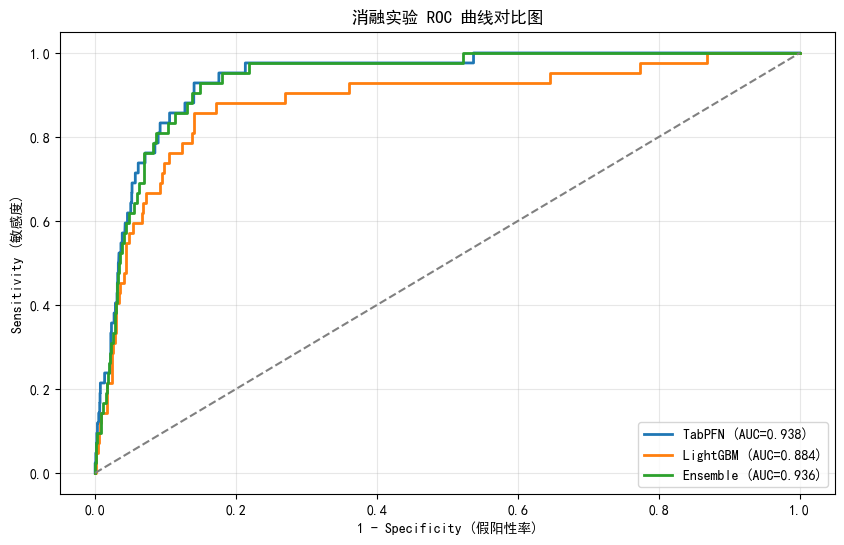


Step 3: 启动 Kernel SHAP 全局解释 (集成模型)...


NameError: name 'perform_kernel_shap' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
import warnings

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

import os
# 1. 设置国内镜像站 (核心步骤)
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_TOKEN"] = ""


# ==================== 1. 完整字段白名单 (151个) ====================
# 包含数值型和类别型，代码会自动匹配 20.xlsx 中实际存在的列
NUM_COLS = [
    'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 'neutrophil_percentage_result', 
    'mature_neutrophil_result', 'neutrophil_count_result', 'ngal_result', 'neutrophil_classification_result', 
    'neutrophil_pnh_clone_result', 'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 
    'albumin_result', 'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
    'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
    'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
    'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
    'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
    'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
    'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
    'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
    'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
    'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 'monocyte_absolute_count_result', 
    'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 'systolic_bp_result', 'spo2_result_value', 
    'lactate_result', 'procalcitonin_result', 'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 
    'potassium_result', 'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 
    'platelet_crit_result', 'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
]

CAT_COLS = [
    'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 'procalcitonin_conclusion', 
    'hs_crp_conclusion', 'd_dimer_conclusion', 'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 
    'ngal_conclusion', 'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
    'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
    'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
    'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
    'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
    'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
    'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
    'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
    'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
    'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
    'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
    'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
    'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
    'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
    'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
    'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
    'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
    'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
]

# ==================== 2. 核心逻辑主程序 ====================
def main():
    # 2.1 数据加载与白名单过滤
    print("Step 1: 正在从 20.xlsx 加载数据...")
    try:
        df = pd.read_excel("20.xlsx")

        # 获取原始记录数
        original_count = len(df)
        print(f"原始记录数: {original_count}")

        # 计算每条记录缺少字段的比例（缺失值比例）
        missing_ratio = df.isnull().sum(axis=1) / len(df.columns)

        # 筛选缺少字段小于50%的记录
        df_filtered = df[missing_ratio < 0.8]

        # 显示筛选后的记录数
        filtered_count = len(df_filtered)
        print(f"筛选后记录数: {filtered_count}")
        print(f"删除的记录数: {original_count - filtered_count}")
        df = df_filtered
        df = df.head(11000)

        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
        
        # 提取 Excel 中实际存在的字段
        final_num = [c for c in NUM_COLS if c in df.columns]
        final_cat = [c for c in CAT_COLS if c in df.columns]
        
        print(f"字段匹配成功：数值特征({len(final_num)}个), 类别特征({len(final_cat)}个)")
    except Exception as e:
        print(f"读取 Excel 出错，请检查文件名和路径: {e}")
        return

    # 2.2 数据预处理
    # 类别特征编码（TabPFN 需要数值化输入）
    X = df[final_num + final_cat].copy()
    for col in final_cat:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].fillna("Unknown").astype(str))
    
    # 缺失值中位数填充
    imputer = SimpleImputer(strategy='median')
    X_filled = imputer.fit_transform(X)
    y = df[target_name].values

    # 数据划分
    X_train, X_test, y_train, y_test = train_test_split(
        X_filled, y, test_size=0.2, stratify=y, random_state=42
    )

    # 2.3 消融实验：训练独立模型与集成模型
    print("\nStep 2: 开始消融实验训练...")
    
    # --- 模型 A: TabPFN ---
    print("[Ablation] 运行 TabPFN (基于Transformer的先验模型)...")
    # TabPFN 预测较快，但在大数据集上可能需要采样，此处使用默认配置
    classifier_tabpfn = TabPFNClassifier(device='cuda')
    classifier_tabpfn.fit(X_train, y_train)
    p_tabpfn = classifier_tabpfn.predict_proba(X_test)[:, 1]

    # --- 模型 B: LightGBM ---
    print("[Ablation] 训练 LightGBM (经典梯度提升树)...")
    classifier_lgb = lgb.LGBMClassifier(is_unbalance=True, n_estimators=100, verbosity=-1, random_state=42)
    classifier_lgb.fit(X_train, y_train)
    p_lgb = classifier_lgb.predict_proba(X_test)[:, 1]

    # --- 模型 C: Ensemble (TabPFN + LGBM) ---
    # 采用加权融合 0.5:0.5
    p_ensemble = (0.5 * p_tabpfn) + (0.5 * p_lgb)

    # 2.4 评估函数定义
    def evaluate_model(probs, labels, name):
        fpr, tpr, thresholds = roc_curve(labels, probs)
        auc_score = auc(fpr, tpr)
        # 选取特异性 >= 0.90 的最近点作为临床参考阈值
        idx = np.where(fpr <= 0.10)[0][-1]
        t = thresholds[idx]
        y_pred = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()
        
        return {
            "模型": name,
            "AUC": round(auc_score, 4),
            "敏感度(Sens)": round(tp/(tp+fn), 4),
            "特异性(Spec)": round(tn/(tn+fp), 4),
            "精确率(Prec)": round(tp/(tp+fp), 4),
            "误诊数(FP)": fp,
            "漏诊数(FN)": fn
        }

    # 2.5 消融实验对比表
    results = [
        evaluate_model(p_tabpfn, y_test, "TabPFN Only"),
        evaluate_model(p_lgb, y_test, "LightGBM Only"),
        evaluate_model(p_ensemble, y_test, "Ensemble (TabPFN+LGBM)")
    ]
    
    df_results = pd.DataFrame(results)
    print("\n" + "="*80)
    print("                      消融实验：20.xlsx 诊断性能对比表")
    print("="*80)
    print(df_results.to_string(index=False))
    print("="*80)

    # 2.6 可视化 ROC 对比曲线
    plt.figure(figsize=(10, 6))
    for p, name in zip([p_tabpfn, p_lgb, p_ensemble], ["TabPFN", "LightGBM", "Ensemble"]):
        f, t, _ = roc_curve(y_test, p)
        plt.plot(f, t, lw=2, label=f'{name} (AUC={auc(f,t):.3f})')
    
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('1 - Specificity (假阳性率)')
    plt.ylabel('Sensitivity (敏感度)')
    plt.title('消融实验 ROC 曲线对比图')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    # 定义集成预测函数（放在 main 内部可以访问到已经训练好的模型变量）
    def ensemble_predict(data):
        p1 = classifier_tabpfn.predict_proba(data)[:, 1]
        p2 = classifier_lgb.predict_proba(data)[:, 1]
        return (0.5 * p1 + 0.5 * p2)

    # 准备特征名称列表
    feature_names = final_num + final_cat
    
    # --- 在这里调用 SHAP 分析 ---
    print("\nStep 3: 启动 Kernel SHAP 全局解释 (集成模型)...")
    # 注意：为了速度，建议 X_test 只选前 20-50 个样本
    explainer, kernel_vals = perform_kernel_shap(
        ensemble_predict, 
        X_train, 
        X_test, 
        feature_names
    )

if __name__ == "__main__":
    main()

Step 1: 正在加载数据并预处理...

Step 2: 模型训练中...


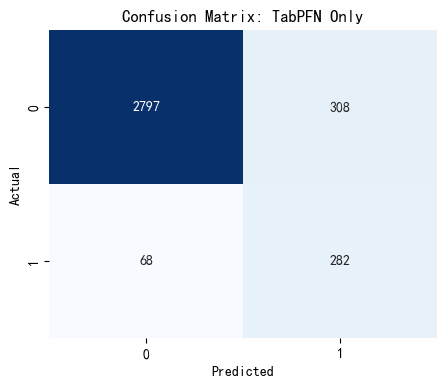

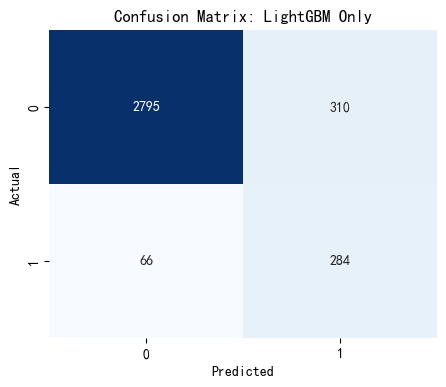

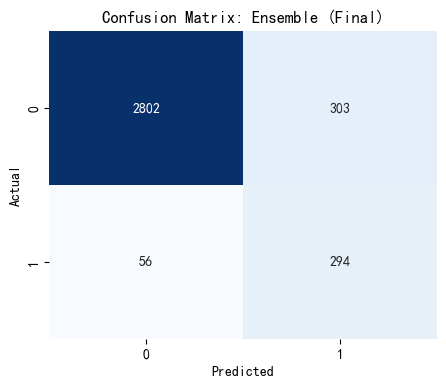


              模型    AUC  F1-Score  Accuracy  Sensitivity  Specificity    MCC
     TabPFN Only 0.9394    0.6000    0.8912       0.8057       0.9008 0.5665
   LightGBM Only 0.9398    0.6017    0.8912       0.8114       0.9002 0.5690
Ensemble (Final) 0.9419    0.6209    0.8961       0.8400       0.9024 0.5925

正在计算 SHAP 值 (选取 5 个样本)...


  0%|          | 0/5 [00:00<?, ?it/s]

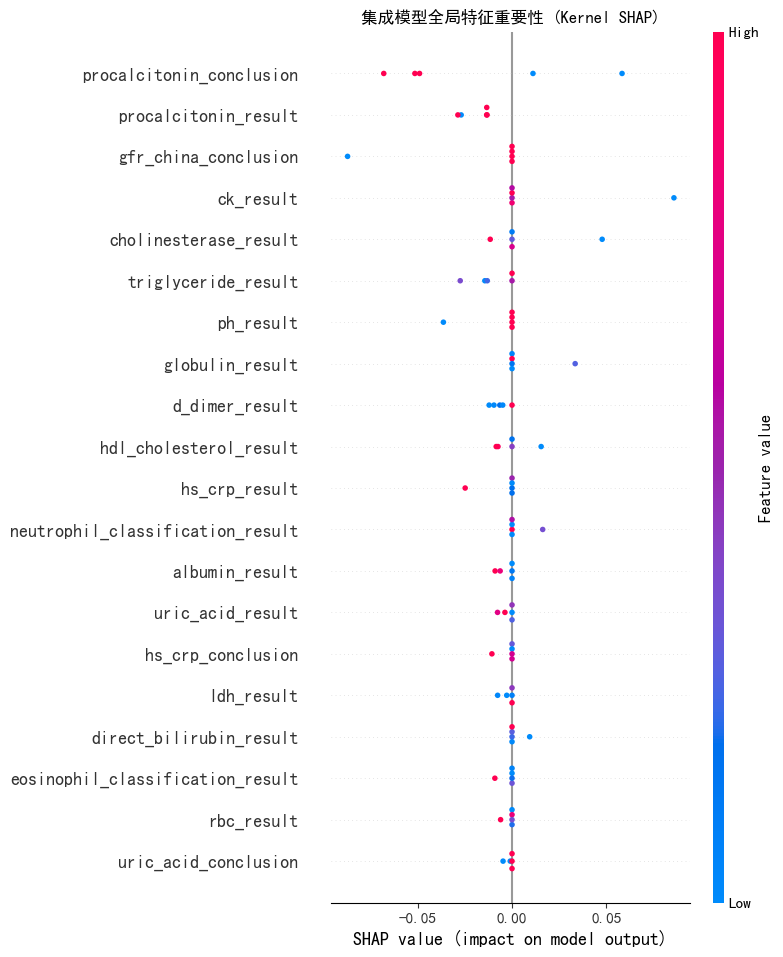

In [ ]:
#正式使用的版本
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, 
                             f1_score, accuracy_score, matthews_corrcoef, classification_report)
import warnings
import os
import shap
import random
import torch

%config InlineBackend.figure_format = 'svg'

# ===== 全局随机种子 =====
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 设置国内镜像站及 Token (请确保 Token 有效)
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_TOKEN"] = ""

# ==================== 1. 特征字段定义 ====================
NUM_COLS = [
    'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 'neutrophil_percentage_result', 
    'mature_neutrophil_result', 'neutrophil_count_result', 'ngal_result', 'neutrophil_classification_result', 
    'neutrophil_pnh_clone_result', 'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 
    'albumin_result', 'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
    'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
    'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
    'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
    'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
    'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
    'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
    'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
    'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
    'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 'monocyte_absolute_count_result', 
    'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 'systolic_bp_result', 'spo2_result_value', 
    'lactate_result', 'procalcitonin_result', 'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 
    'potassium_result', 'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 
    'platelet_crit_result', 'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
]

CAT_COLS = [
    'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 'procalcitonin_conclusion', 
    'hs_crp_conclusion', 'd_dimer_conclusion', 'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 
    'ngal_conclusion', 'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
    'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
    'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
    'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
    'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
    'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
    'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
    'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
    'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
    'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
    'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
    'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
    'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
    'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
    'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
    'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
    'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
    'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
]

# ==================== 2. 辅助函数 ====================
def perform_kernel_shap(predict_fn, X_train, X_test, feature_names, n_background=20, n_test=5):
    """执行 Kernel SHAP 解释"""
    print(f"\n正在计算 SHAP 值 (选取 {n_test} 个样本)...")
    # Kernel SHAP 极慢，背景数据需要高度压缩
    background_summary = shap.kmeans(X_train, n_background)
    explainer = shap.KernelExplainer(predict_fn, background_summary)
    
    # 抽取少量测试样本
    test_samples = X_test[:n_test]
    shap_values = explainer.shap_values(test_samples)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, test_samples, feature_names=feature_names, show=False)
    plt.title("集成模型全局特征重要性 (Kernel SHAP)")
    plt.show()
    plt.savefig('ensemble_shap_1.png', dpi=600, bbox_inches='tight')
    return explainer, shap_values

# ==================== 3. 核心逻辑主程序 ====================
def main():
    # 3.1 数据加载
    print("Step 1: 正在加载数据并预处理...")
    try:
        df = pd.read_excel("20-1缺失率小于0.4的.xlsx")

        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
        final_num = [c for c in NUM_COLS if c in df.columns]
        final_cat = [c for c in CAT_COLS if c in df.columns]
    except Exception as e:
        print(f"读取文件失败: {e}"); return

    # 数据编码与填充
    X = df[final_num + final_cat].copy()
    for col in final_cat:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].fillna("Unknown").astype(str))
    
    imputer = SimpleImputer(strategy='median')
    X_filled = imputer.fit_transform(X)
    y = df[target_name].values

    X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, stratify=y, random_state=42)

    # 3.2 消融实验：模型训练
    print("\nStep 2: 模型训练中...")
    
    # TabPFN
    clf_tabpfn = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
    clf_tabpfn.fit(X_train, y_train)
    p_tabpfn = clf_tabpfn.predict_proba(X_test)[:, 1]

    # LightGBM
    clf_lgb = lgb.LGBMClassifier(is_unbalance=True, n_estimators=100, verbosity=-1, random_state=42)
    clf_lgb.fit(X_train, y_train)
    p_lgb = clf_lgb.predict_proba(X_test)[:, 1]

    # Ensemble
    p_ensemble = (0.5 * p_tabpfn) + (0.5 * p_lgb)

    # 3.3 增强版评估函数
    def evaluate_and_plot(probs, labels, name):
        fpr, tpr, thresholds = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)
        
        # 自动选择最佳阈值 (此处示例使用临床常用：Spec >= 0.90)
        idx = np.where(fpr <= 0.10)[0][-1]
        threshold = thresholds[idx]
        y_pred = (probs >= threshold).astype(int)
        
        # 计算核心指标
        cm = confusion_matrix(labels, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # 绘制混淆矩阵
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.show()

        return {
            "模型": name,
            "AUC": round(roc_auc, 4),
            "F1-Score": round(f1_score(labels, y_pred), 4),
            "Accuracy": round(accuracy_score(labels, y_pred), 4),
            "Sensitivity": round(tp/(tp+fn), 4),
            "Specificity": round(tn/(tn+fp), 4),
            "MCC": round(matthews_corrcoef(labels, y_pred), 4)
        }

    # 3.4 性能对比展现
    results = [
        evaluate_and_plot(p_tabpfn, y_test, "TabPFN Only"),
        evaluate_and_plot(p_lgb, y_test, "LightGBM Only"),
        evaluate_and_plot(p_ensemble, y_test, "Ensemble (Final)")
    ]
    
    print("\n" + "="*85)
    print(pd.DataFrame(results).to_string(index=False))
    print("="*85)

    # 3.5 启动 SHAP 解释
    def ensemble_predict_fn(x_np):
        # 包装函数供 SHAP 使用
        p1 = clf_tabpfn.predict_proba(x_np)[:, 1]
        p2 = clf_lgb.predict_proba(x_np)[:, 1]
        return 0.5 * p1 + 0.5 * p2

    perform_kernel_shap(
        ensemble_predict_fn, 
        X_train, 
        X_test, 
        final_num + final_cat
    )

if __name__ == "__main__":
    import torch
    main()

Step 1: 正在加载数据并预处理...

Step 2: 模型训练中...


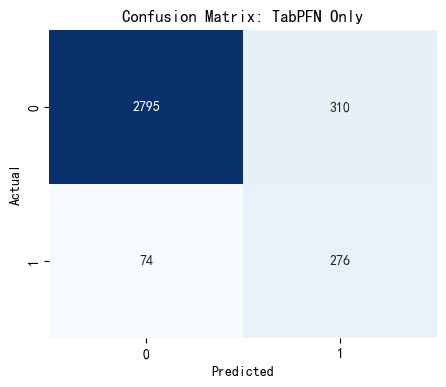

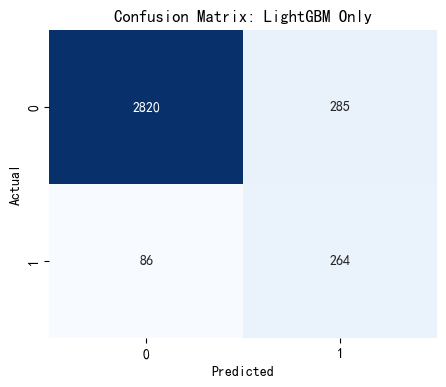

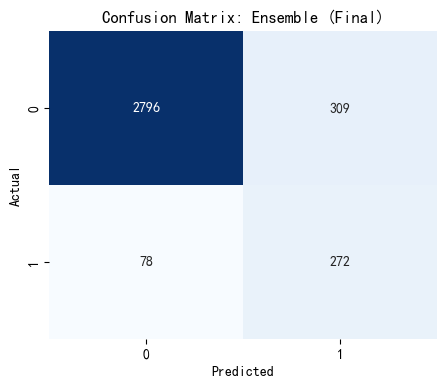


              模型    AUC  F1-Score  Accuracy  Sensitivity  Specificity    MCC
     TabPFN Only 0.9355    0.5897    0.8889       0.7886       0.9002 0.5537
   LightGBM Only 0.9301    0.5873    0.8926       0.7543       0.9082 0.5468
Ensemble (Final) 0.9347    0.5843    0.8880       0.7771       0.9005 0.5467

正在计算 SHAP 值 (选取 5 个样本)...


  0%|          | 0/5 [00:00<?, ?it/s]


--- 每个样本影响最大的前 3 个特征分析 ---

[样本 ID: 0]
  特征: procalcitonin_conclusion  | 原始值: 2.0        | SHAP值:  -0.0812 (负向(↓))
  特征: uric_acid_conclusion      | 原始值: 0.0        | SHAP值:  -0.0314 (负向(↓))
  特征: hs_crp_conclusion         | 原始值: 3.0        | SHAP值:  -0.0311 (负向(↓))

[样本 ID: 1]
  特征: procalcitonin_conclusion  | 原始值: 2.0        | SHAP值:  -0.0739 (负向(↓))
  特征: d_dimer_conclusion        | 原始值: 1.0        | SHAP值:  -0.0246 (负向(↓))
  特征: hemoglobin_conclusion     | 原始值: 5.0        | SHAP值:  -0.0188 (负向(↓))

[样本 ID: 2]
  特征: gfr_china_conclusion      | 原始值: 0.0        | SHAP值:  -0.0998 (负向(↓))
  特征: ck_conclusion             | 原始值: 2.0        | SHAP值:  -0.0160 (负向(↓))
  特征: pt_conclusion             | 原始值: 3.0        | SHAP值:  -0.0142 (负向(↓))

[样本 ID: 3]
  特征: procalcitonin_conclusion  | 原始值: 1.0        | SHAP值:   0.0848 (正向(↑))
  特征: cholinesterase_conclusion | 原始值: 1.0        | SHAP值:   0.0463 (正向(↑))
  特征: hs_crp_conclusion         | 原始值: 0.0        | SHAP值:   0.0273 (正向(↑))

[样本 ID: 4]


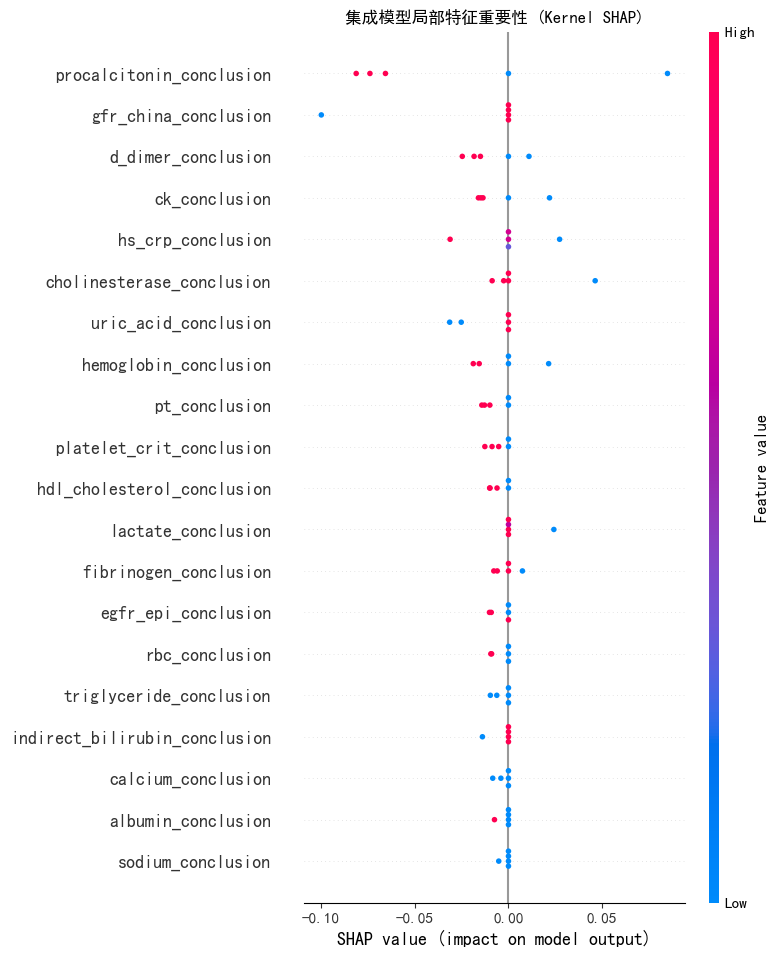

In [ ]:
#正式使用的版本，去除带result的字段
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, 
                             f1_score, accuracy_score, matthews_corrcoef, classification_report)
import warnings
import os
import shap
import random
import torch

# ===== 全局随机种子 =====
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 设置国内镜像站及 Token (请确保 Token 有效)
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_TOKEN"] = ""

# ==================== 1. 特征字段定义 ====================
NUM_COLS = [
    'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 'neutrophil_percentage_result', 
    'mature_neutrophil_result', 'neutrophil_count_result', 'ngal_result', 'neutrophil_classification_result', 
    'neutrophil_pnh_clone_result', 'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 
    'albumin_result', 'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
    'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
    'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
    'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
    'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
    'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
    'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
    'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
    'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
    'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 'monocyte_absolute_count_result', 
    'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 'systolic_bp_result', 'spo2_result_value', 
    'lactate_result', 'procalcitonin_result', 'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 
    'potassium_result', 'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 
    'platelet_crit_result', 'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
]

CAT_COLS = [
    'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 'procalcitonin_conclusion', 
    'hs_crp_conclusion', 'd_dimer_conclusion', 'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 
    'ngal_conclusion', 'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
    'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
    'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
    'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
    'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
    'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
    'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
    'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
    'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
    'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
    'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
    'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
    'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
    'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
    'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
    'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
    'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
    'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
]

# ==================== 2. 辅助函数 ====================
def perform_kernel_shapold(predict_fn, X_train, X_test, feature_names, n_background=20, n_test=5):
    """执行 Kernel SHAP 解释"""
    print(f"\n正在计算 SHAP 值 (选取 {n_test} 个样本)...")
    # Kernel SHAP 极慢，背景数据需要高度压缩
    background_summary = shap.kmeans(X_train, n_background)
    explainer = shap.KernelExplainer(predict_fn, background_summary)
    
    # 抽取少量测试样本
    test_samples = X_test[:n_test]
    shap_values = explainer.shap_values(test_samples)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, test_samples, feature_names=feature_names, show=False)
    plt.title("集成模型全局特征重要性 (Kernel SHAP)")
    plt.show()
    plt.savefig('ensemble_shap_2.png', dpi=600, bbox_inches='tight')
    return explainer, shap_values

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def perform_kernel_shap(predict_fn, X_train, X_test, feature_names, n_background=20, n_test=5, top_k=3):
    """执行 Kernel SHAP 解释并打印每个样本最重要的特征值"""
    print(f"\n正在计算 SHAP 值 (选取 {n_test} 个样本)...")
    
    # 1. 压缩背景数据
    background_summary = shap.kmeans(X_train, n_background)
    explainer = shap.KernelExplainer(predict_fn, background_summary)
    
    # 2. 抽取测试样本并计算 SHAP 值
    # 确保 X_test 是 DataFrame 以便方便提取特征值，如果不是则转换
    if not isinstance(X_test, pd.DataFrame):
        test_samples = pd.DataFrame(X_test[:n_test], columns=feature_names)
    else:
        test_samples = X_test.iloc[:n_test]
        
    shap_values = explainer.shap_values(test_samples)

    # 3. 打印每个样本的最重要特征
    print(f"\n--- 每个样本影响最大的前 {top_k} 个特征分析 ---")
    
    # Kernel SHAP 对于二分类可能返回 list [neg_shap, pos_shap]，取 pos_shap
    actual_shap = shap_values[1] if isinstance(shap_values, list) else shap_values

    for i in range(n_test):
        print(f"\n[样本 ID: {i}]")
        # 获取当前样本的所有特征的 SHAP 绝对值
        abs_shaps = np.abs(actual_shap[i])
        # 找到绝对值最大的前 k 个索引
        top_indices = np.argsort(abs_shaps)[-top_k:][::-1]
        
        for idx in top_indices:
            fname = feature_names[idx]
            fval = test_samples.iloc[i, idx]
            s_val = actual_shap[i][idx]
            influence = "正向(↑)" if s_val > 0 else "负向(↓)"
            print(f"  特征: {fname:<25} | 原始值: {fval:<10} | SHAP值: {s_val:>8.4f} ({influence})")

    # 4. 绘图与保存
    plt.figure(figsize=(10, 6))
    shap.summary_plot(actual_shap, test_samples, feature_names=feature_names, show=False)
    plt.title("集成模型局部特征重要性 (Kernel SHAP)")
    plt.savefig('ensemble_shap_2.png', dpi=600, bbox_inches='tight')
    plt.show()
    
    return explainer, shap_values
    
# ==================== 3. 核心逻辑主程序 ====================
def main():
    # 3.1 数据加载
    print("Step 1: 正在加载数据并预处理...")
    try:
        df = pd.read_excel("20-1缺失率小于0.4的.xlsx")
        df = df[[col for col in df.columns if 'result' not in col]]

        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
        final_num = [c for c in NUM_COLS if c in df.columns]
        final_cat = [c for c in CAT_COLS if c in df.columns]
    except Exception as e:
        print(f"读取文件失败: {e}"); return

    # 数据编码与填充
    X = df[final_num + final_cat].copy()
    for col in final_cat:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].fillna("Unknown").astype(str))
    
    imputer = SimpleImputer(strategy='median')
    X_filled = imputer.fit_transform(X)
    y = df[target_name].values

    X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, stratify=y, random_state=42)

    # 3.2 消融实验：模型训练
    print("\nStep 2: 模型训练中...")
    
    # TabPFN
    clf_tabpfn = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
    clf_tabpfn.fit(X_train, y_train)
    p_tabpfn = clf_tabpfn.predict_proba(X_test)[:, 1]

    # LightGBM
    clf_lgb = lgb.LGBMClassifier(is_unbalance=True, n_estimators=100, verbosity=-1, random_state=42)
    clf_lgb.fit(X_train, y_train)
    p_lgb = clf_lgb.predict_proba(X_test)[:, 1]

    # Ensemble
    p_ensemble = (0.5 * p_tabpfn) + (0.5 * p_lgb)

    # 3.3 增强版评估函数
    def evaluate_and_plot(probs, labels, name):
        fpr, tpr, thresholds = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)
        
        # 自动选择最佳阈值 (此处示例使用临床常用：Spec >= 0.90)
        idx = np.where(fpr <= 0.10)[0][-1]
        threshold = thresholds[idx]
        y_pred = (probs >= threshold).astype(int)
        
        # 计算核心指标
        cm = confusion_matrix(labels, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # 绘制混淆矩阵
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.show()

        return {
            "模型": name,
            "AUC": round(roc_auc, 4),
            "F1-Score": round(f1_score(labels, y_pred), 4),
            "Accuracy": round(accuracy_score(labels, y_pred), 4),
            "Sensitivity": round(tp/(tp+fn), 4),
            "Specificity": round(tn/(tn+fp), 4),
            "MCC": round(matthews_corrcoef(labels, y_pred), 4)
        }

    # 3.4 性能对比展现
    results = [
        evaluate_and_plot(p_tabpfn, y_test, "TabPFN Only"),
        evaluate_and_plot(p_lgb, y_test, "LightGBM Only"),
        evaluate_and_plot(p_ensemble, y_test, "Ensemble (Final)")
    ]
    
    print("\n" + "="*85)
    print(pd.DataFrame(results).to_string(index=False))
    print("="*85)

    # 3.5 启动 SHAP 解释
    def ensemble_predict_fn(x_np):
        # 包装函数供 SHAP 使用
        p1 = clf_tabpfn.predict_proba(x_np)[:, 1]
        p2 = clf_lgb.predict_proba(x_np)[:, 1]
        return 0.5 * p1 + 0.5 * p2

    perform_kernel_shap(
        ensemble_predict_fn, 
        X_train, 
        X_test, 
        final_num + final_cat
    )

if __name__ == "__main__":
    import torch
    main()

Step 1: 正在加载数据并预处理...
原始数据集总样本数: 17274
------------------------------
训练集样本数 (X_train): 13819 (占比 80.0%)
测试集样本数 (X_test):  3455 (占比 20.0%)
------------------------------
训练集阳性率 (y_train == 1): 10.12%
测试集阳性率 (y_test == 1):  10.13%

Step 2: 模型训练中...


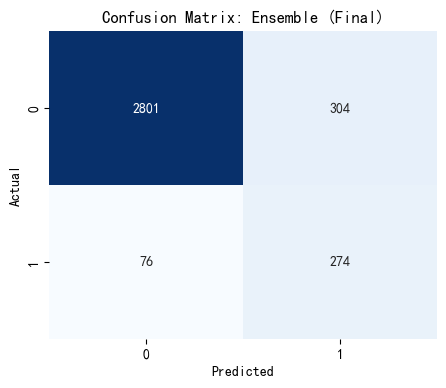

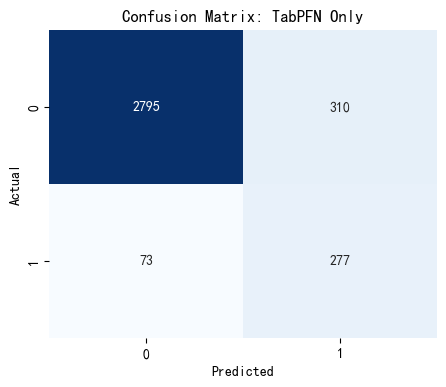

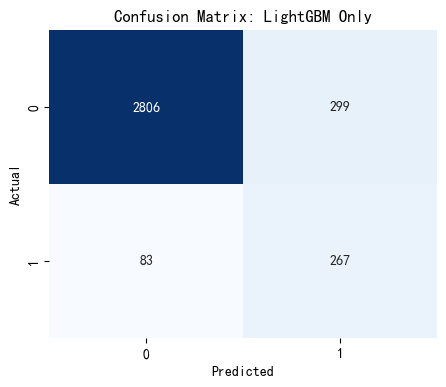


                                                                                                                                         0         1        2        3           4           5    6
 {'模型': 'TabPFN Only', 'AUC': 0.9328, 'F1-Score': 0.5912, 'Accuracy': 0.8891, 'Sensitivity': 0.7914, 'Specificity': 0.9002, 'MCC': 0.5557}  0.182229     None     None        None        None None
{'模型': 'LightGBM Only', 'AUC': 0.9285, 'F1-Score': 0.583, 'Accuracy': 0.8894, 'Sensitivity': 0.7629, 'Specificity': 0.9037, 'MCC': 0.5434}  0.490054     None     None        None        None None
                                                                                                                                        模型       AUC F1-Score Accuracy Sensitivity Specificity  MCC

正在计算 SHAP 值 (选取了 5 个【脓毒症阳性】样本)...


  0%|          | 0/5 [00:00<?, ?it/s]


--- 阳性样本(y=1)影响最大的前 3 个特征分析 ---

[局部序号: 0 | 原始索引: 9]
实际标签: 1 | 预测标签: 1  【真阳性-预测正确】
  特征: gfr_china_result          | 原始值: 0.2077385509073715 | SHAP值:   0.1756 (正向(↑))
  特征: procalcitonin_result      | 原始值: 0.02245158544371142 | SHAP值:   0.0895 (正向(↑))
  特征: cholinesterase_result     | 原始值: 0.03451821386603995 | SHAP值:   0.0556 (正向(↑))

[局部序号: 1 | 原始索引: 44]
实际标签: 1 | 预测标签: 0  【假阴性-漏诊！】
  特征: procalcitonin_result      | 原始值: 0.0009576505639497765 | SHAP值:  -0.0596 (负向(↓))
  特征: gfr_china_result          | 原始值: 0.2077385509073715 | SHAP值:   0.0496 (正向(↑))
  特征: d_dimer_result            | 原始值: 0.001160420260310491 | SHAP值:  -0.0189 (负向(↓))

[局部序号: 2 | 原始索引: 48]
实际标签: 1 | 预测标签: 1  【真阳性-预测正确】
  特征: gfr_china_result          | 原始值: 0.2077385509073715 | SHAP值:   0.1713 (正向(↑))
  特征: ck_result                 | 原始值: 0.001728891173309658 | SHAP值:   0.1008 (正向(↑))
  特征: heart_rate_result         | 原始值: 0.109375   | SHAP值:   0.0326 (正向(↑))

[局部序号: 3 | 原始索引: 76]
实际标签: 1 | 预测标签: 1  【真阳性-预测正确】
  特征

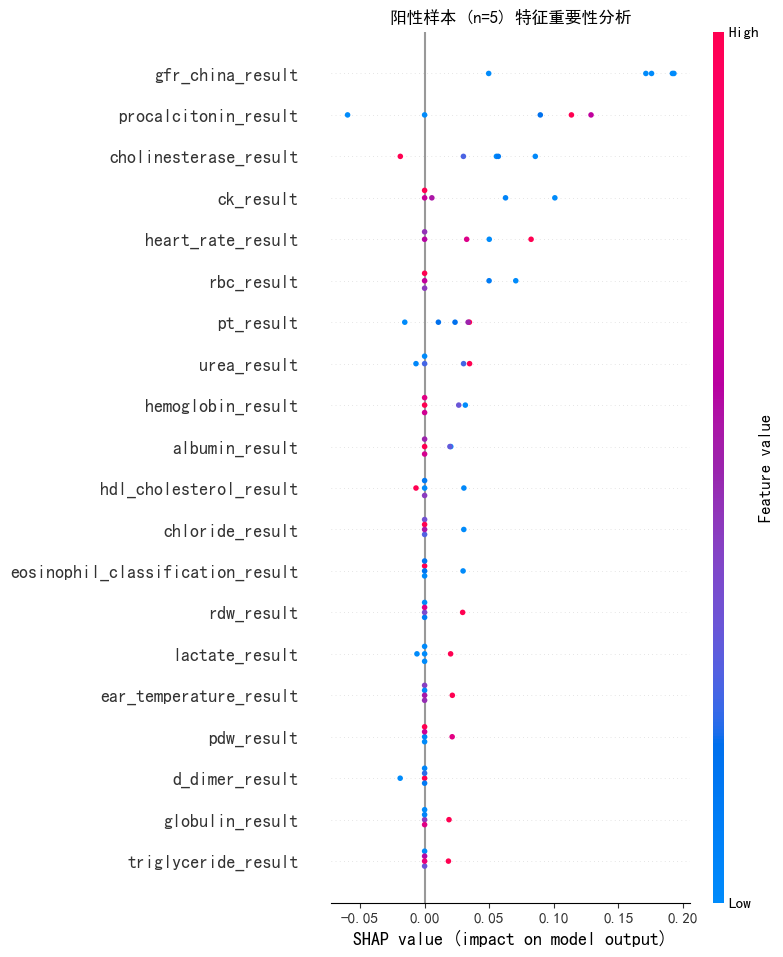

<Figure size 800x500 with 0 Axes>

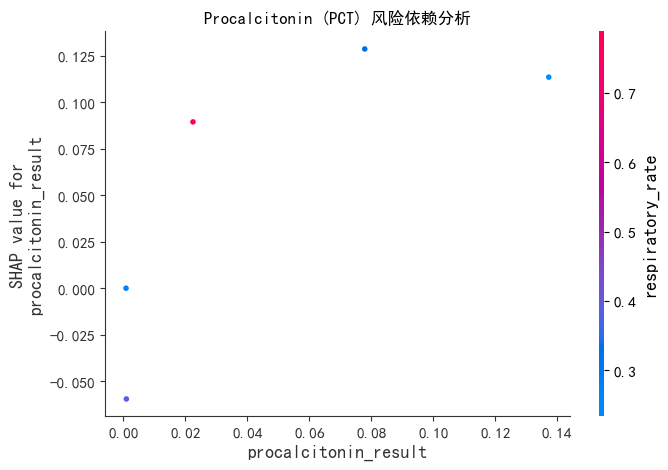

<Figure size 800x500 with 0 Axes>

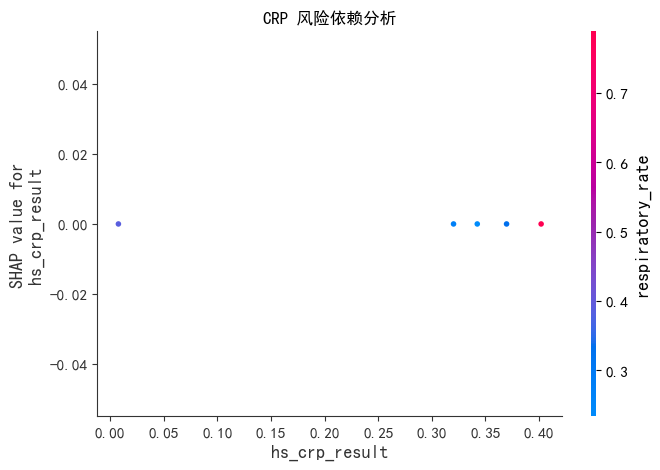

<Figure size 800x500 with 0 Axes>

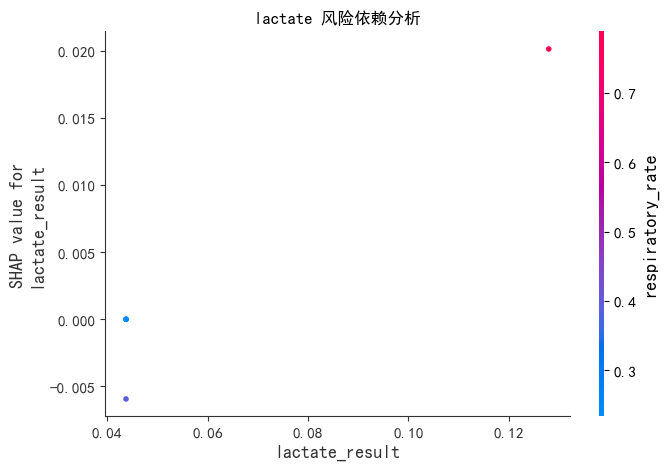

<Figure size 800x500 with 0 Axes>

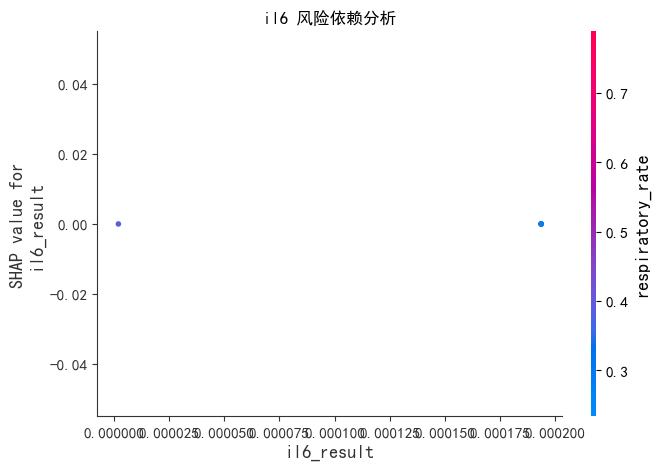

<Figure size 800x500 with 0 Axes>

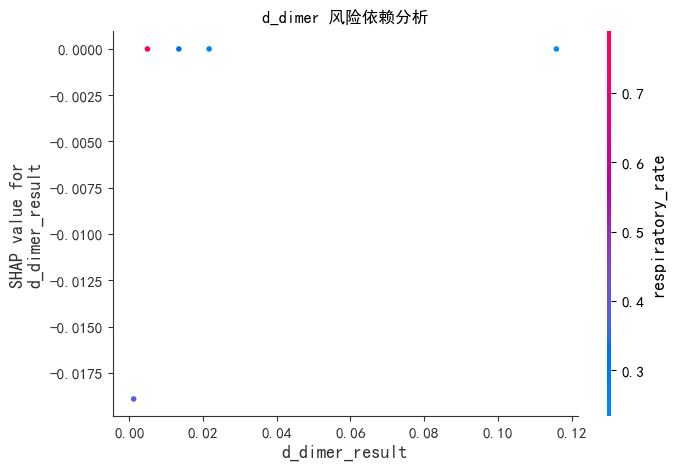

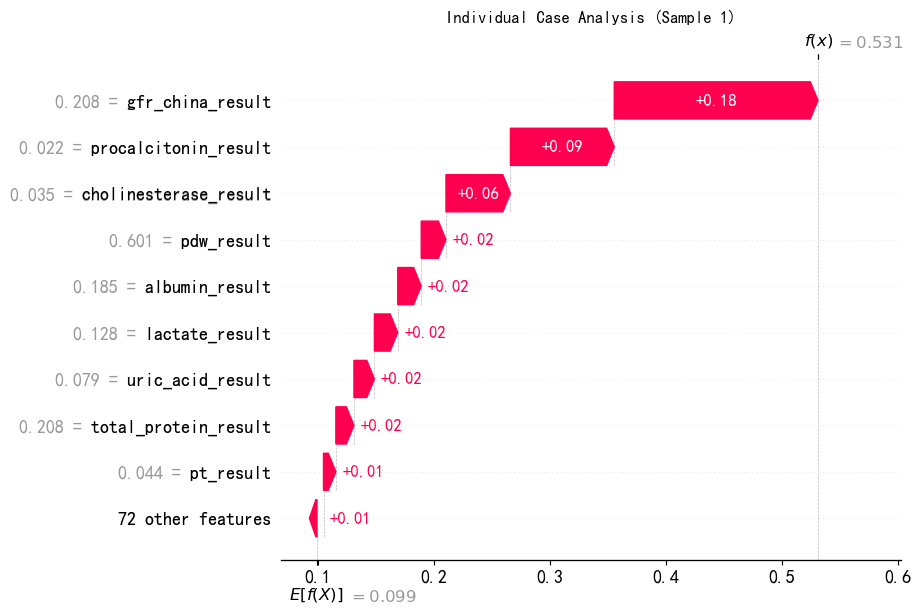

In [ ]:
#正式使用的版本，去除带conclusion的字段
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabpfn import TabPFNClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, 
                             f1_score, accuracy_score, matthews_corrcoef, classification_report)
import warnings
import os
import shap
import random
import torch

# ===== 全局随机种子 =====
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

# ==================== 0. 基础设置 ====================
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 设置国内镜像站及 Token (请确保 Token 有效)
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_TOKEN"] = ""

# ==================== 1. 特征字段定义 ====================
NUM_COLS = [
    'respiratory_rate', 'temperature_result', 'il6_result', 'd_dimer_result', 'neutrophil_percentage_result', 
    'mature_neutrophil_result', 'neutrophil_count_result', 'ngal_result', 'neutrophil_classification_result', 
    'neutrophil_pnh_clone_result', 'neutrophil_absolute_count_result', 'absolute_neutrophil_count_result', 
    'albumin_result', 'total_protein_result', 'basophilic_metamyelocyte_result', 'neutrophil_alkaline_phosphatase_result', 
    'eosinophil_classification_result', 'basophilic_segmented_neutrophil_result', 'basophilic_myelocyte_result', 
    'acidophilic_metamyelocyte_result', 'neutrophil_stab_cell_result', 'neutrophil_metamyelocyte_result', 
    'basophil_count_result', 'monocyte_percentage_result', 'wbc_result', 'direct_bilirubin_result', 
    'calcium_result', 'magnesium_result', 'chloride_result', 'phosphate_result', 'cholinesterase_result', 
    'ldl_cholesterol_result', 'globulin_result', 'total_cholesterol_result', 'platelet_count_result', 
    'rbc_result', 'rdw_result', 'mcv_result', 'hct_result', 'mch_result', 'mchc_result', 'gfr_cys_result', 
    'gfr_china_result', 'gfr_epi_result', 'egfr_cys_result', 'egfr_china_result', 'egfr_epi_result', 
    'creatinine_result', 'indirect_bilirubin_result', 'uric_acid_result', 'hdl_cholesterol_result', 
    'ast_result', 'alt_result', 'alp_result', 'ggt_result', 'triglyceride_result', 'monocyte_absolute_count_result', 
    'heart_rate_result', 'spo2_result', 'diastolic_bp_result', 'systolic_bp_result', 'spo2_result_value', 
    'lactate_result', 'procalcitonin_result', 'ear_temperature_result', 'hs_crp_result', 'hemoglobin_result', 
    'potassium_result', 'sodium_result', 'pt_result', 'tt_result', 'ldh_result', 'urea_result', 
    'platelet_crit_result', 'mpv_result', 'pdw_result', 'ph_result', 'fibrinogen_result', 'ck_result'
]

CAT_COLS = [
    'gender', 'spo2_conclusion', 'il6_conclusion', 'lactate_conclusion', 'procalcitonin_conclusion', 
    'hs_crp_conclusion', 'd_dimer_conclusion', 'neutrophil_percentage_conclusion', 'neutrophil_count_conclusion', 
    'ngal_conclusion', 'neutrophil_classification_conclusion', 'neutrophil_pnh_clone_conclusion', 
    'absolute_neutrophil_count_conclusion', 'albumin_conclusion', 'total_protein_conclusion', 
    'hemoglobin_conclusion', 'basophilic_metamyelocyte_conclusion', 'neutrophil_alkaline_phosphatase_conclusion', 
    'eosinophil_classification_conclusion', 'basophilic_segmented_neutrophil_conclusion', 
    'basophilic_myelocyte_conclusion', 'acidophilic_metamyelocyte_conclusion', 'neutrophil_stab_cell_conclusion', 
    'neutrophil_metamyelocyte_conclusion', 'basophil_count_conclusion', 'monocyte_percentage_conclusion', 
    'wbc_conclusion', 'direct_bilirubin_conclusion', 'potassium_conclusion', 'calcium_conclusion', 
    'sodium_conclusion', 'magnesium_conclusion', 'chloride_conclusion', 'phosphate_conclusion', 
    'cholinesterase_conclusion', 'ldl_cholesterol_conclusion', 'globulin_conclusion', 'pt_conclusion', 
    'tt_conclusion', 'ldh_conclusion', 'total_cholesterol_conclusion', 'urea_conclusion', 
    'platelet_count_conclusion', 'platelet_crit_conclusion', 'mpv_conclusion', 'pdw_conclusion', 
    'rbc_conclusion', 'rdw_conclusion', 'mcv_conclusion', 'hct_conclusion', 'mch_conclusion', 
    'mchc_conclusion', 'gfr_cys_conclusion', 'gfr_china_conclusion', 'gfr_epi_conclusion', 
    'egfr_cys_conclusion', 'egfr_china_conclusion', 'egfr_epi_conclusion', 'ck_conclusion', 
    'creatinine_conclusion', 'indirect_bilirubin_conclusion', 'uric_acid_conclusion', 
    'hdl_cholesterol_conclusion', 'ast_conclusion', 'alt_conclusion', 'alp_conclusion', 
    'ggt_conclusion', 'fibrinogen_conclusion', 'triglyceride_conclusion', 
    'monocyte_absolute_count_conclusion', 'ph_conclusion', 'age_group'
]

# ==================== 2. 辅助函数 ====================
def perform_kernel_shapold(predict_fn, X_train, X_test, feature_names, n_background=20, n_test=5):
    """执行 Kernel SHAP 解释"""
    print(f"\n正在计算 SHAP 值 (选取 {n_test} 个样本)...")
    # Kernel SHAP 极慢，背景数据需要高度压缩
    background_summary = shap.kmeans(X_train, n_background)
    explainer = shap.KernelExplainer(predict_fn, background_summary)
    
    # 抽取少量测试样本
    test_samples = X_test[:n_test]
    shap_values = explainer.shap_values(test_samples)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, test_samples, feature_names=feature_names, show=False)
    plt.title("集成模型全局特征重要性 (Kernel SHAP)")
    plt.show()
    plt.savefig('ensemble_shap_3.png', dpi=600, bbox_inches='tight')
    return explainer, shap_values
    
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def perform_kernel_shap(predict_fn, X_train, X_test, y_test, feature_names,threshold=0.5, n_background=20, n_test=5, top_k=3):
    """
    执行 Kernel SHAP 解释，增加实际标签与预测标签的显示
    """
    # 1. 筛选标签为 1 的样本
    if not isinstance(X_test, pd.DataFrame):
        X_test_df = pd.DataFrame(X_test, columns=feature_names)
    else:
        X_test_df = X_test.reset_index(drop=True)
    
    # 确保 y_test 是 numpy 数组格式方便索引
    y_test_arr = np.array(y_test)
    
    # 找到所有 y=1 的原始索引
    pos_indices = np.where(y_test_arr == 1)[0]
    
    if len(pos_indices) < n_test:
        print(f"⚠️ 警告：标签为 1 的样本总数仅有 {len(pos_indices)} 个，将全部进行计算。")
        selected_indices = pos_indices
    else:
        selected_indices = pos_indices[:n_test]
    
    test_samples = X_test_df.iloc[selected_indices]
    
    # 获取预测值 (通常 predict_fn 返回概率或类别，这里假设获取类别标签)
    # 如果 predict_fn 返回的是概率，可以用 (preds > 0.5).astype(int) 转换
    y_probs = predict_fn(test_samples)
    y_pred_all = (y_probs >= threshold).astype(int)
    #y_pred_all = predict_fn(test_samples) 
    
    print(f"\n正在计算 SHAP 值 (选取了 {len(test_samples)} 个【脓毒症阳性】样本)...")
    
    # 2. 压缩背景数据与初始化
    background_summary = shap.kmeans(X_train, n_background)
    explainer = shap.KernelExplainer(predict_fn, background_summary)
    
    # 3. 计算 SHAP 值
    shap_values = explainer.shap_values(test_samples)
    actual_shap = shap_values[1] if isinstance(shap_values, list) else shap_values

    # 4. 打印详细分析
    print(f"\n--- 阳性样本(y=1)影响最大的前 {top_k} 个特征分析 ---")
    
    for i in range(len(test_samples)):
        original_idx = selected_indices[i]
        real_label = y_test_arr[original_idx]
        pred_label = y_pred_all[i]
        
        # 临床状态判断
        status = "【真阳性-预测正确】" if real_label == pred_label else "【假阴性-漏诊！】"
        
        print(f"\n[局部序号: {i} | 原始索引: {original_idx}]")
        print(f"实际标签: {real_label} | 预测标签: {pred_label}  {status}")
        
        # 提取 Top K 特征
        abs_shaps = np.abs(actual_shap[i])
        top_indices = np.argsort(abs_shaps)[-top_k:][::-1]
        
        for idx in top_indices:
            fname = feature_names[idx]
            fval = test_samples.iloc[i, idx]
            s_val = actual_shap[i][idx]
            influence = "正向(↑)" if s_val > 0 else "负向(↓)"
            print(f"  特征: {fname:<25} | 原始值: {fval:<10} | SHAP值: {s_val:>8.4f} ({influence})")

    # 5. 绘图与保存
    plt.figure(figsize=(10, 6))
    shap.summary_plot(actual_shap, test_samples, feature_names=feature_names, show=False)
    plt.title(f"阳性样本 (n={len(test_samples)}) 特征重要性分析")
    plt.savefig('positive_samples_shap.png', dpi=600, bbox_inches='tight')

    # --- 新加：依赖图 (Dependence Plot) ---
    # 这一步会生成一个新的图形，放在 summary_plot 之后
    # 它会自动找到与 procalcitonin_conclusion 相互作用最强的特征作为颜色轴
    plt.figure(figsize=(8, 5)) # 为新图创建一个新的画布，防止重叠
    shap.dependence_plot("procalcitonin_result", actual_shap, test_samples, show=False)
    plt.title("Procalcitonin (PCT) 风险依赖分析")
    plt.savefig('d_pct_dependence_plot_3.png', dpi=600, bbox_inches='tight')

    # 它会自动找到与 procalcitonin_conclusion 相互作用最强的特征作为颜色轴
    plt.figure(figsize=(8, 5)) # 为新图创建一个新的画布，防止重叠
    shap.dependence_plot("hs_crp_result", actual_shap, test_samples, show=False)
    plt.title("CRP 风险依赖分析")
    plt.savefig('case_1_d_crp_dependence_plot_3.png', dpi=600, bbox_inches='tight')

    plt.figure(figsize=(8, 5)) # 为新图创建一个新的画布，防止重叠
    shap.dependence_plot("lactate_result", actual_shap, test_samples, show=False)
    plt.title("lactate 风险依赖分析")
    plt.savefig('d_lactate_dependence_plot_3.png', dpi=600, bbox_inches='tight')

    plt.figure(figsize=(8, 5)) # 为新图创建一个新的画布，防止重叠
    shap.dependence_plot("il6_result", actual_shap, test_samples, show=False)
    plt.title("il6 风险依赖分析")
    plt.savefig('d_il6_dependence_plot_3.png', dpi=600, bbox_inches='tight')

    plt.figure(figsize=(8, 5)) # 为新图创建一个新的画布，防止重叠
    shap.dependence_plot("d_dimer_result", actual_shap, test_samples, show=False)
    plt.title("d_dimer 风险依赖分析")
    plt.savefig('d_dimer_dependence_plot_3.png', dpi=600, bbox_inches='tight')

    # --- 3. Waterfall Plot (个体病例拆解) ---
    # 注意：Waterfall 需要 .explain_instance 产生的对象
    # 这里我们演示解释测试集中的第一个样本 (index 0)
    plt.figure(figsize=(10, 6))
    # 重新构建一个针对单个样本的 Explanation 对象（适应新版 SHAP 接口）
    exp = shap.Explanation(
        values=actual_shap[0], 
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=test_samples.iloc[0].values,
        feature_names=feature_names
    )
    shap.plots.waterfall(exp, show=False)
    plt.title("Individual Case Analysis (Sample 1)")
    plt.savefig('case_0_waterfall.png', dpi=600, bbox_inches='tight')
    
    plt.show()
    
    return explainer, shap_values
    
# ==================== 3. 核心逻辑主程序 ====================
def main():
    # 3.1 数据加载
    print("Step 1: 正在加载数据并预处理...")
    try:
        df = pd.read_excel("20-1缺失率小于0.4的.xlsx")
        df = df[[col for col in df.columns if 'conclusion' not in col]]

        target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
        final_num = [c for c in NUM_COLS if c in df.columns]
        final_cat = [c for c in CAT_COLS if c in df.columns]
    except Exception as e:
        print(f"读取文件失败: {e}"); return

    # 数据编码与填充
    X = df[final_num + final_cat].copy()
    for col in final_cat:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].fillna("Unknown").astype(str))
    
    imputer = SimpleImputer(strategy='median')
    X_filled = imputer.fit_transform(X)
    y = df[target_name].values

    X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, stratify=y, random_state=42)

    # 打印样本数
    print(f"原始数据集总样本数: {len(X_filled)}")
    print("-" * 30)
    print(f"训练集样本数 (X_train): {X_train.shape[0]} (占比 {X_train.shape[0]/len(X_filled):.1%})")
    print(f"测试集样本数 (X_test):  {X_test.shape[0]} (占比 {X_test.shape[0]/len(X_filled):.1%})")

    # 验证分层效果（脓毒症阳性占比）
    print("-" * 30)
    print(f"训练集阳性率 (y_train == 1): {y_train.sum() / len(y_train):.2%}")
    print(f"测试集阳性率 (y_test == 1):  {y_test.sum() / len(y_test):.2%}")

    # 3.2 消融实验：模型训练
    print("\nStep 2: 模型训练中...")
    
    # TabPFN
    clf_tabpfn = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
    clf_tabpfn.fit(X_train, y_train)
    p_tabpfn = clf_tabpfn.predict_proba(X_test)[:, 1]

    # LightGBM
    clf_lgb = lgb.LGBMClassifier(is_unbalance=True, n_estimators=100, verbosity=-1, random_state=42)
    clf_lgb.fit(X_train, y_train)
    p_lgb = clf_lgb.predict_proba(X_test)[:, 1]

    # Ensemble
    p_ensemble = (0.5 * p_tabpfn) + (0.5 * p_lgb)

    # 3.3 增强版评估函数
    def evaluate_and_plot(probs, labels, name):
        fpr, tpr, thresholds = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)
        
        # 自动选择最佳阈值 (此处示例使用临床常用：Spec >= 0.90)
        idx = np.where(fpr <= 0.10)[0][-1]
        threshold = thresholds[idx]
        y_pred = (probs >= threshold).astype(int)
        
        # 计算核心指标
        cm = confusion_matrix(labels, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        # 绘制混淆矩阵
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.show()

        metrics = {
            "模型": name,
            "AUC": round(roc_auc, 4),
            "F1-Score": round(f1_score(labels, y_pred), 4),
            "Accuracy": round(accuracy_score(labels, y_pred), 4),
            "Sensitivity": round(tp/(tp+fn), 4),
            "Specificity": round(tn/(tn+fp), 4),
            "MCC": round(matthews_corrcoef(labels, y_pred), 4)
        }
        return metrics, threshold  # 修改点：返回指标的同时返回阈值

    # 3.4 性能对比展现
    res_ensemble, final_threshold = evaluate_and_plot(p_ensemble, y_test, "Ensemble (Final)")
    results = [
        evaluate_and_plot(p_tabpfn, y_test, "TabPFN Only"),
        evaluate_and_plot(p_lgb, y_test, "LightGBM Only"),
        res_ensemble
    ]
    
    print("\n" + "="*85)
    print(pd.DataFrame(results).to_string(index=False))
    print("="*85)

    # 3.5 启动 SHAP 解释
    def ensemble_predict_fn(x_np):
        # 包装函数供 SHAP 使用
        p1 = clf_tabpfn.predict_proba(x_np)[:, 1]
        p2 = clf_lgb.predict_proba(x_np)[:, 1]
        return 0.5 * p1 + 0.5 * p2

    perform_kernel_shap(
        ensemble_predict_fn, 
        X_train, 
        X_test, 
        y_test, 
        final_num + final_cat,
        threshold=final_threshold
    )

if __name__ == "__main__":
    import torch
    main()

In [3]:
 import shap
import matplotlib.pyplot as plt

def plot_feature_interactions(shap_values, X_test, feature_names):
    """
    生成 SHAP 依赖图以展示特征间的交互作用
    """
    # 转换为 DataFrame 方便索引
    X_df = pd.DataFrame(X_test, columns=feature_names)
    
    # 1. 交互作用 A: Procalcitonin vs. Cholinesterase
    # 探讨：当胆碱酯酶（CHE）水平不同时，PCT 浓度的增加如何影响风险
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        "procalcitonin_result", 
        shap_values, 
        X_df, 
        interaction_index="cholinesterase_result",
        show=False
    )
    plt.title("Interaction: Procalcitonin and Cholinesterase")
    plt.savefig("interaction_pct_che.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 2. 交互作用 B: Procalcitonin vs. Neutrophil Classification
    # 探讨：炎症指标与免疫分类的协同预警效应
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        "procalcitonin_result", 
        shap_values, 
        X_df, 
        interaction_index="neutrophil_classification_result",
        show=False
    )
    plt.title("Interaction: Procalcitonin and Neutrophil Dynamics")
    plt.savefig("interaction_pct_neutrophil.png", dpi=300, bbox_inches='tight')
    plt.show()

# 调用示例
plot_feature_interactions(kernel_vals, X_test[:50], final_num + final_cat)

NameError: name 'kernel_vals' is not defined

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, chi2_contingency

def generate_table_1(df, target_col, num_cols, cat_cols):
    table_1_data = []
    groups = df.groupby(target_col)
    
    # 遍历数值特征
    for col in num_cols:
        if col not in df.columns: continue
        
        stats = {}
        stats['Characteristic'] = col
        
        # 计算两组的均值/中位数
        for name, group in groups:
            group_data = group[col].dropna()
            # 进行正态性检验
            _, p_norm = shapiro(group_data[:500]) if len(group_data) > 500 else shapiro(group_data)
            
            if p_norm > 0.05: # 正态分布
                stats[f'Group {name}'] = f"{group_data.mean():.2f} ± {group_data.std():.2f}"
                test_type = 't-test'
            else: # 非正态分布
                stats[f'Group {name}'] = f"{group_data.median():.2f} ({group_data.quantile(0.25):.2f}-{group_data.quantile(0.75):.2f})"
                test_type = 'MWU'
        
        # 组间显著性检验 (P-value)
        g0 = df[df[target_col] == 0][col].dropna()
        g1 = df[df[target_col] == 1][col].dropna()
        if test_type == 't-test':
            _, p_val = ttest_ind(g0, g1)
        else:
            _, p_val = mannwhitneyu(g0, g1)
            
        stats['P-value'] = f"{p_val:.4f}"
        table_1_data.append(stats)

    # 遍历类别特征
    for col in cat_cols:
        if col not in df.columns: continue
        # 这里简化处理：展示计数和百分比
        counts = df.groupby([target_col, col]).size().unstack(fill_value=0)
        # 卡方检验
        _, p_val, _, _ = chi2_contingency(counts)
        
        table_1_data.append({
            'Characteristic': f"{col} (n, %)",
            'Group 0': "See detail", # 实际写作时通常展开具体类别
            'Group 1': "See detail",
            'P-value': f"{p_val:.4f}"
        })

    return pd.DataFrame(table_1_data)

# 使用示例 (假设 df 是你的 20.xlsx 加载后的 Dataframe)
df = pd.read_excel("20-1.xlsx")
target_name = 'sepsis_diagnosis' if 'sepsis_diagnosis' in df.columns else 'target'
table_1 = generate_table_1(df, 'sepsis_diagnosis', NUM_COLS, CAT_COLS)
table_1.to_csv("Table_1_Baseline.csv", index=False)